# 🎮 Arbori de Decizie în Jocuri Video

## NPC Warrior — Alegerea Acțiunii Optime

Un personaj NPC (Non-Player Character) de tip **Warrior** trebuie sa decida ce actiune st execute la fiecare pas din joc, pe baza sttrii curente a lumii.

### Features (intrări):
| Feature | Descriere | Valori |
|---|---|---|
| `health_pct` | Procentul de HP al NPC-ului | 0–100 |
| `enemy_distance` | Distanta fațta de inamic (unitati) | 1–50 |
| `ammo` | Munitie ramasa | 0–30 |
| `ally_nearby` | Exista aliat în raza? | 0/1 |
| `enemy_health_pct` | HP-ul inamicului | 0–100 |
| `cover_available` | Exista adapost in zona? | 0/1 |

### Acțiuni (tinta):
| Label | Actiune |
|---|---|
| `ATTACK` | Ataca inamicul |
| `RETREAT` | Retrage-te pentru recuperare |
| `TAKE_COVER` | Du-te la adapost |
| `CALL_ALLY` | Cheama intariri |

## 1. Importuri

In [ ]:
# biblioteca pentru vizualizare tree
!pip install -q dtreeviz

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✅ Importuri complete!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 1.9 MB/s eta 0:00:00
✅ Importuri complete!


## 2. Generare set de date sintetic

In [ ]:
def generate_game_dataset(n_samples=1500):
    """
    Genereaza un set de date sintetic care simuleaza deciziile unui NPC Warrior.
    Regulile reflecta logica de joc:
      - HP scazut + adapost disponibil     → TAKE_COVER
      - HP scazut + fara adapost           → RETREAT
      - HP ok + inamicul aproape + munitie → ATTACK
      - HP ok + aliat in zona              → CALL_ALLY (presiune coordonata)
      - altfel                             → ATTACK default
    """
    health       = np.random.randint(5, 101, n_samples)
    enemy_dist   = np.random.randint(1, 51, n_samples)
    ammo         = np.random.randint(0, 31, n_samples)
    ally_nearby  = np.random.randint(0, 2, n_samples)
    enemy_hp     = np.random.randint(5, 101, n_samples)
    cover        = np.random.randint(0, 2, n_samples)

    actions = []
    for i in range(n_samples):
        h, d, a, al, eh, cv = (
            health[i], enemy_dist[i], ammo[i],
            ally_nearby[i], enemy_hp[i], cover[i]
        )
        # Reguli de decizie deterministe
        if h < 30 and cv == 1:
            action = 'TAKE_COVER'
        elif h < 30 and cv == 0:
            action = 'RETREAT'
        elif h >= 30 and d <= 10 and a >= 5:
            action = 'ATTACK'
        elif h >= 50 and al == 1 and eh > 60:
            action = 'CALL_ALLY'
        elif h >= 30 and d > 10 and al == 1:
            action = 'CALL_ALLY'
        elif a == 0:
            action = 'RETREAT'
        else:
            action = 'ATTACK'

        actions.append(action)

    df = pd.DataFrame({
        'health_pct'      : health,
        'enemy_distance'  : enemy_dist,
        'ammo'            : ammo,
        'ally_nearby'     : ally_nearby,
        'enemy_health_pct': enemy_hp,
        'cover_available' : cover,
        'action'          : actions
    })

    # Zgomot realist (8% din sample-uri → actiune aleatoare)
    noise_idx = np.random.choice(n_samples, size=int(0.08 * n_samples), replace=False)
    all_actions = ['ATTACK', 'RETREAT', 'TAKE_COVER', 'CALL_ALLY']
    df.loc[noise_idx, 'action'] = np.random.choice(all_actions, size=len(noise_idx))

    return df


df = generate_game_dataset(1500)
print(f'Dataset: {df.shape[0]} inregistrari, {df.shape[1]} coloane')
print()
print('Distributia claselor:')
print(df['action'].value_counts())
df.head(10)

Dataset: 1500 inregistrari, 7 coloane

Distributia claselor:
action
ATTACK        622
CALL_ALLY     433
TAKE_COVER    235
RETREAT       210
Name: count, dtype: int64


,health_pct,enemy_distance,ammo,ally_nearby,enemy_health_pct,cover_available,action
0,56,26,5,1,98,0,CALL_ALLY
1,97,41,3,0,17,0,ATTACK
2,19,45,19,0,81,0,TAKE_COVER
3,76,26,15,1,70,0,CALL_ALLY
4,65,47,14,0,41,0,ATTACK
5,25,32,26,1,53,0,RETREAT
6,87,10,14,1,70,0,ATTACK
7,91,16,5,1,40,0,ATTACK
8,79,7,14,1,58,1,ATTACK
9,79,17,13,1,30,1,CALL_ALLY


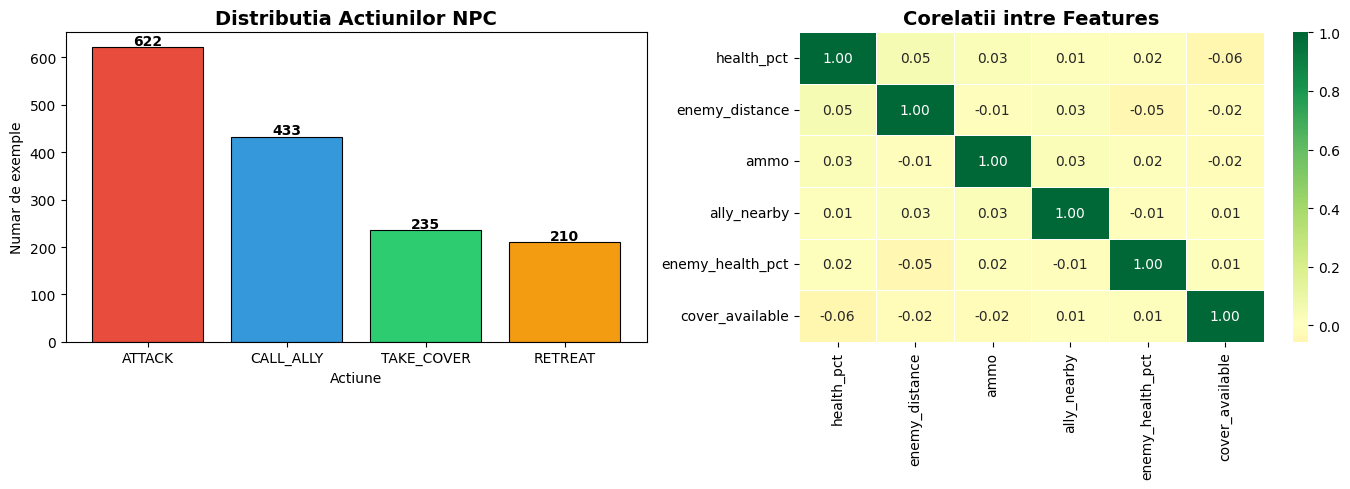

In [ ]:
# Vizualizare distributie clase + statistici features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot clase
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
class_counts = df['action'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distributia Actiunilor NPC', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actiune')
axes[0].set_ylabel('Numar de exemple')
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')

# Heatmap corelatii
numeric_df = df.drop('action', axis=1)
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Corelatii intre Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Pregatire date & split train/test

In [ ]:
FEATURES = ['health_pct', 'enemy_distance', 'ammo',
            'ally_nearby', 'enemy_health_pct', 'cover_available']
TARGET   = 'action'

X = df[FEATURES]
y = df[TARGET]

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} exemple')
print(f'Test:  {X_test.shape[0]} exemple')
print()
print('Distributie clase in train:')
print(y_train.value_counts())
print()
print('Distributie clase in test:')
print(y_test.value_counts())

Train: 1200 exemple
Test:  300 exemple

Distributie clase in train:
action
ATTACK        498
CALL_ALLY     346
TAKE_COVER    188
RETREAT       168
Name: count, dtype: int64

Distributie clase in test:
action
ATTACK        124
CALL_ALLY      87
TAKE_COVER     47
RETREAT        42
Name: count, dtype: int64


## 4. Constructie arbore de decizie

In [ ]:
# --- Model 1: Arbore nerestrictionat ---
dt_full = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_full.fit(X_train, y_train)

# --- Model 2: Arbore limitat ---
dt_pruned = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    min_samples_split=15,
    min_samples_leaf=8,
    random_state=42
)
dt_pruned.fit(X_train, y_train)

print('=== Model 1: Arbore Complet ===')
print(f'  Adancime maxima: {dt_full.get_depth()}')
print(f'  Numar noduri:    {dt_full.get_n_leaves()} frunze')

print()
print('=== Model 2: Arbore Regularizat ===')
print(f'  Adancime maxima: {dt_pruned.get_depth()}')
print(f'  Numar noduri:    {dt_pruned.get_n_leaves()} frunze')

=== Model 1: Arbore Complet ===
  Adancime maxima: 15
  Numar noduri:    150 frunze

=== Model 2: Arbore Regularizat ===
  Adancime maxima: 6
  Numar noduri:    33 frunze


## 5. Evaluare — train vs. test

In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name='Model'):
    """Calculeaza si afiseaza metricile complete pentru train si test."""
    acc_train = accuracy_score(y_tr, model.predict(X_tr))
    acc_test  = accuracy_score(y_te, model.predict(X_te))

    print(f'{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(f'  Acuratete TRAIN : {acc_train*100:.2f}%')
    print(f'  Acuratete TEST  : {acc_test*100:.2f}%')
    gap = acc_train - acc_test
    status = '⚠️ Overfitting!' if gap > 0.05 else '✅ Generalizare buna'
    print(f'  Gap train-test  : {gap*100:.2f}% → {status}')
    print()
    return acc_train, acc_test

acc1_tr, acc1_te = evaluate_model(dt_full,   X_train, y_train, X_test, y_test, 'Arbore Complet (nerestrictionat)')
acc2_tr, acc2_te = evaluate_model(dt_pruned, X_train, y_train, X_test, y_test, 'Arbore Regularizat (max_depth=6)')

#print(f"Acuratete: {dt_full.score(X_test, y_test):.2f}")
#print(f"Acuratete: {dt_pruned.score(X_test, y_test):.2f}")

  Arbore Complet (nerestrictionat)
  Acuratete TRAIN : 100.00%
  Acuratete TEST  : 86.67%
  Gap train-test  : 13.33% → ⚠️ Overfitting!

  Arbore Regularizat (max_depth=6)
  Acuratete TRAIN : 94.00%
  Acuratete TEST  : 93.00%
  Gap train-test  : 1.00% → ✅ Generalizare buna



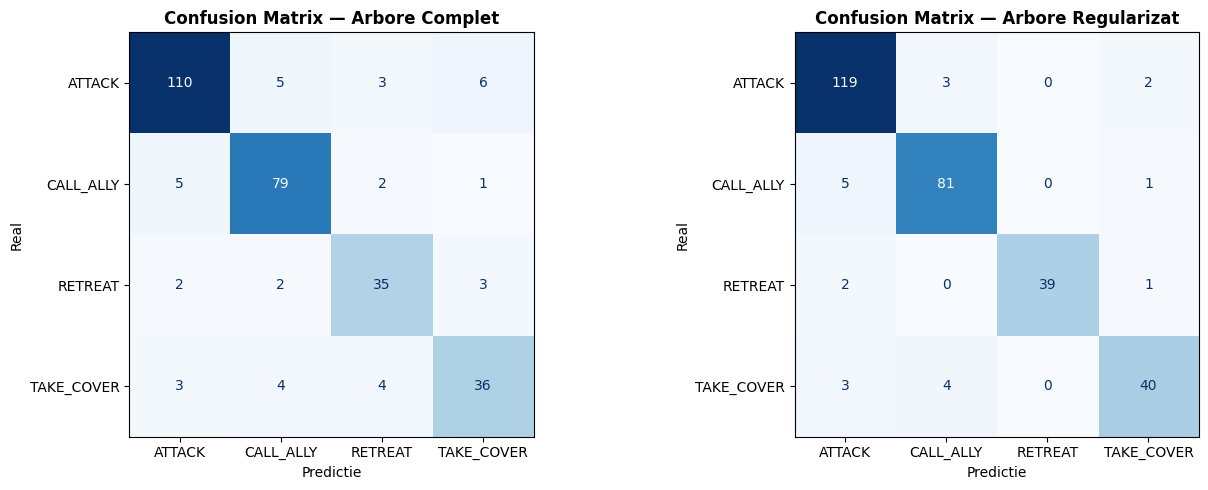

In [ ]:
# Confusion Matrices pentru ambele modele
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(
    axes,
    [dt_full, dt_pruned],
    ['Arbore Complet', 'Arbore Regularizat']
):
    cm = confusion_matrix(y_test, model.predict(X_test),
                          labels=['ATTACK','CALL_ALLY','RETREAT','TAKE_COVER'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['ATTACK','CALL_ALLY','RETREAT','TAKE_COVER']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predictie')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

## 6. Comparatie: acuratete train vs. test la diferite adancimi

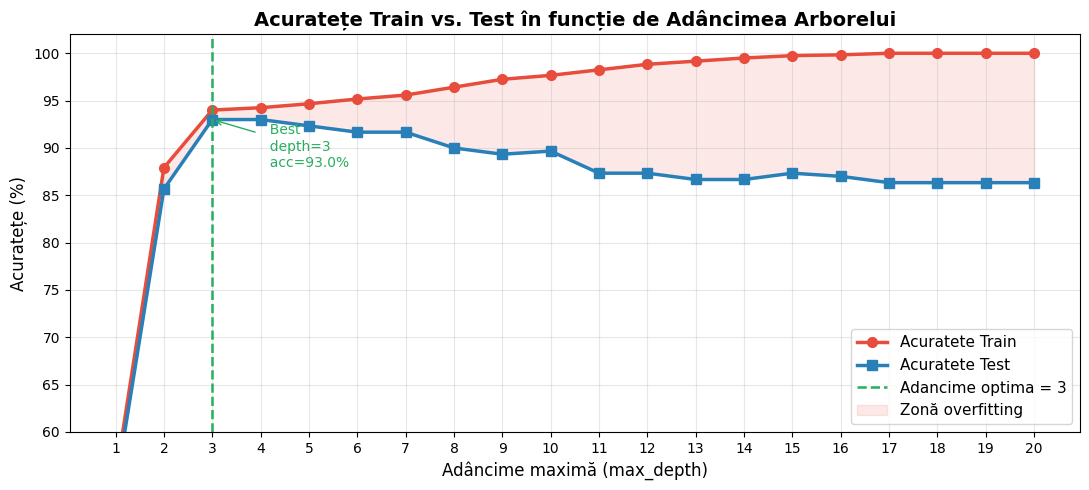

Adancimea optima: 3 → Acuratete test: 93.00%


In [ ]:
depths      = range(1, 21)
train_accs  = []
test_accs   = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  clf.predict(X_test)))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depths, [a*100 for a in train_accs], 'o-', color='#e74c3c',
        linewidth=2.5, markersize=7, label='Acuratete Train')
ax.plot(depths, [a*100 for a in test_accs],  's-', color='#2980b9',
        linewidth=2.5, markersize=7, label='Acuratete Test')

# Marcheaza adancimea optima
best_depth = depths[np.argmax(test_accs)]
best_acc   = max(test_accs) * 100
ax.axvline(x=best_depth, color='#27ae60', linestyle='--', linewidth=1.8,
           label=f'Adancime optima = {best_depth}')
ax.annotate(f'  Best\n  depth={best_depth}\n  acc={best_acc:.1f}%',
            xy=(best_depth, best_acc), xytext=(best_depth+1, best_acc-5),
            fontsize=10, color='#27ae60',
            arrowprops=dict(arrowstyle='->', color='#27ae60'))

ax.fill_between(depths,
                [a*100 for a in train_accs],
                [a*100 for a in test_accs],
                alpha=0.12, color='#e74c3c', label='Zonă overfitting')

ax.set_title('Acuratețe Train vs. Test în funcție de Adâncimea Arborelui',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Adâncime maximă (max_depth)', fontsize=12)
ax.set_ylabel('Acuratețe (%)', fontsize=12)
ax.set_xticks(list(depths))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(60, 102)
plt.tight_layout()
plt.show()

print(f'Adancimea optima: {best_depth} → Acuratete test: {best_acc:.2f}%')

## 7. Importanta caracteristicilor

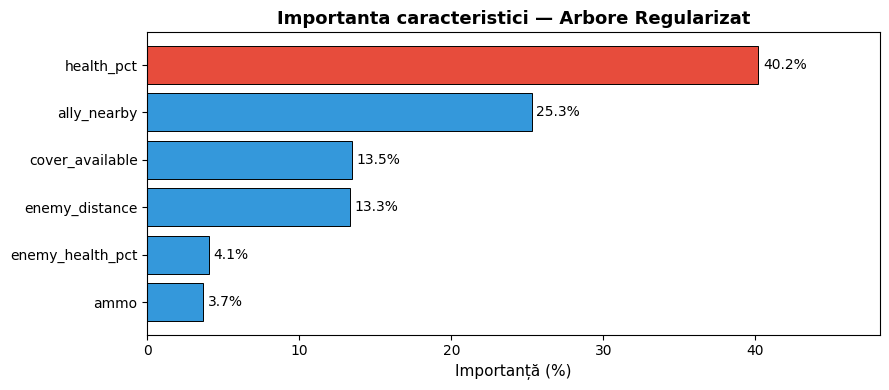

Caracteristica cea mai importanta: health_pct (40.2%)


In [ ]:
importances = pd.Series(dt_pruned.feature_importances_, index=FEATURES)\
               .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = ['#e74c3c' if v == importances.max() else '#3498db' for v in importances]
bars = ax.barh(importances.index, importances.values * 100,
               color=colors_bar, edgecolor='black', linewidth=0.7)

for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)

ax.set_title('Importanta caracteristici — Arbore Regularizat',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importanță (%)', fontsize=11)
ax.set_xlim(0, importances.max()*100 + 8)
plt.tight_layout()
plt.show()

print('Caracteristica cea mai importanta:', importances.idxmax(),
      f'({importances.max()*100:.1f}%)')

## 8. Vizualizarea arborelui de decizie

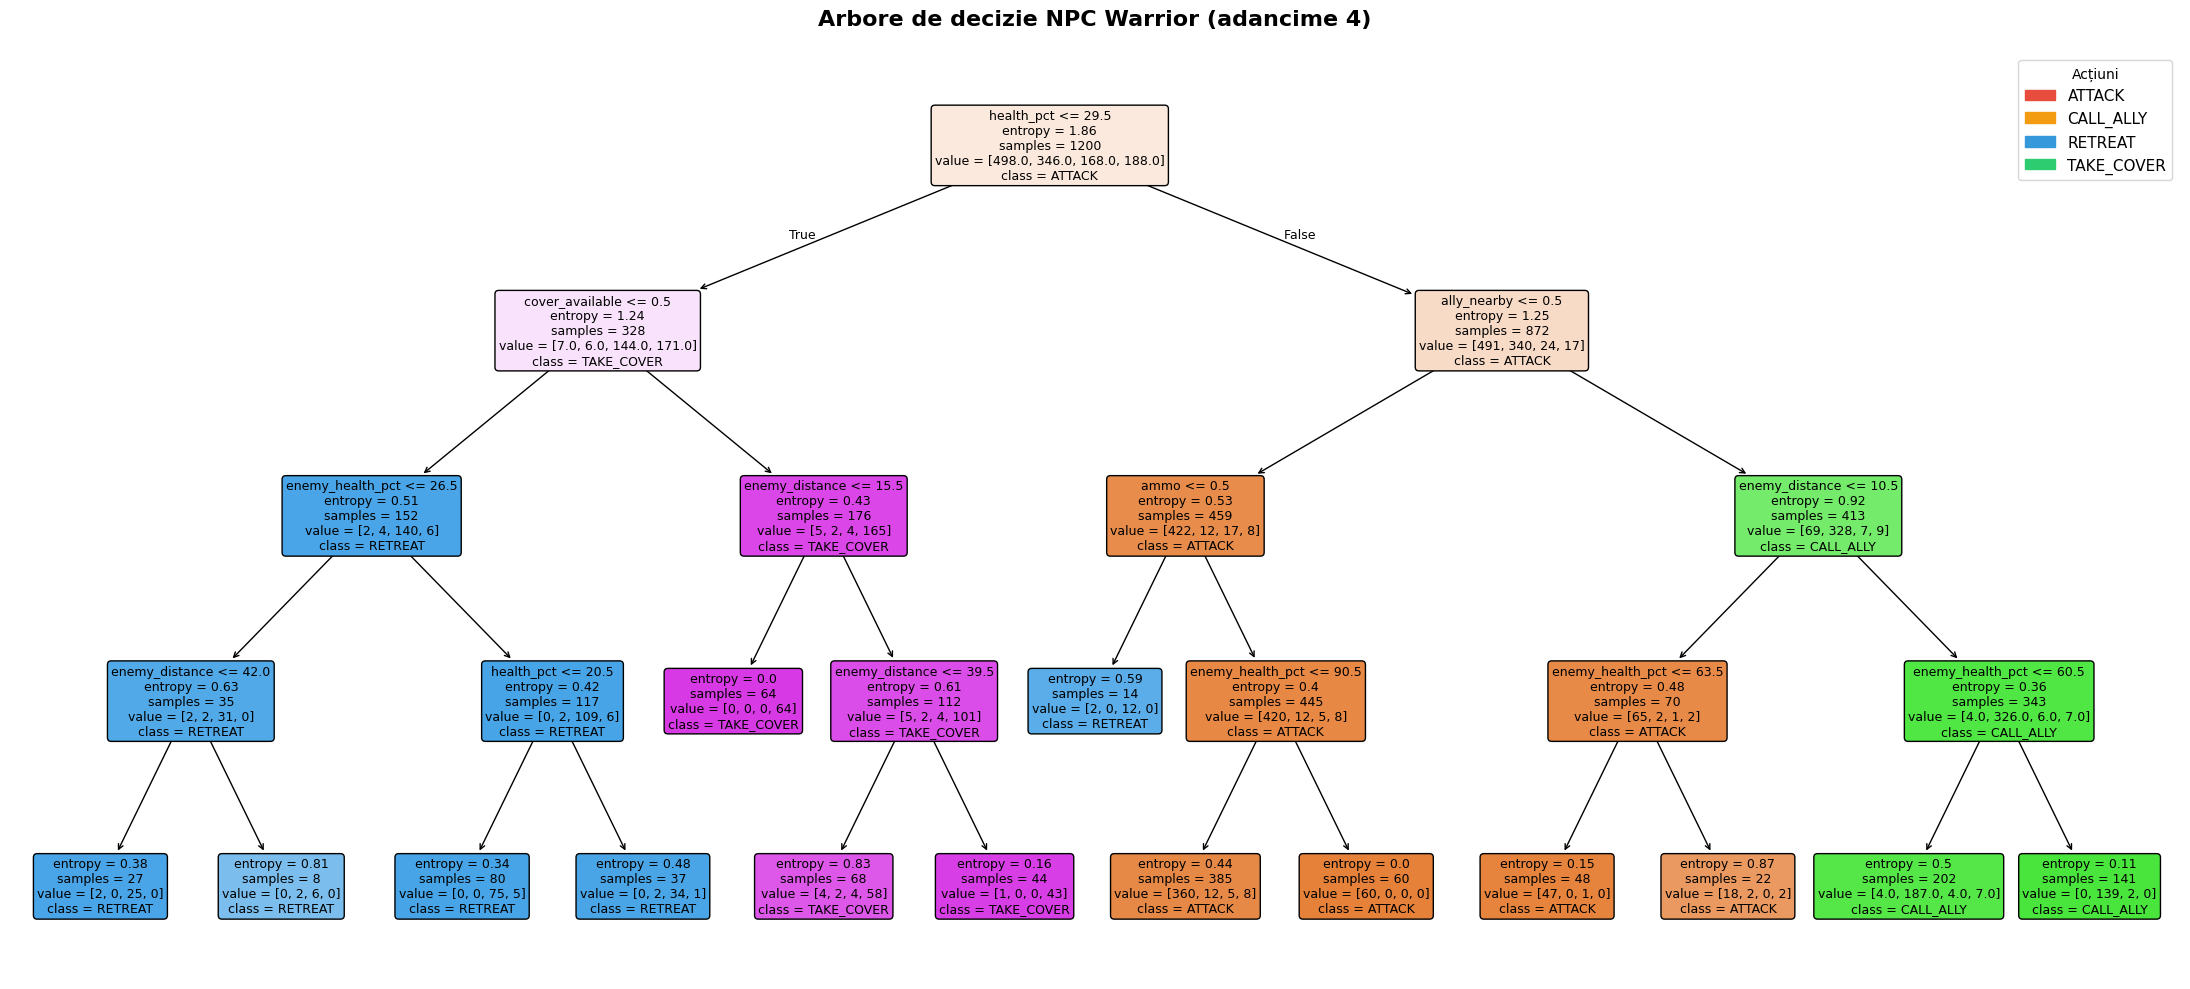

Acuratete test (depth=4): 93.00%


In [ ]:
# Arbore vizual (adancime 4)
dt_viz = DecisionTreeClassifier(
    criterion='entropy', max_depth=4,
    min_samples_split=15, min_samples_leaf=8,
    random_state=42
)
dt_viz.fit(X_train, y_train)

class_names = sorted(y.unique())
color_map   = {'ATTACK': '#e74c3c', 'CALL_ALLY': '#f39c12',
                'RETREAT': '#3498db', 'TAKE_COVER': '#2ecc71'}

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_viz,
    feature_names=FEATURES,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False,
    precision=2
)
ax.set_title('Arbore de decizie NPC Warrior (adancime 4)',
             fontsize=16, fontweight='bold', pad=20)

# Legendă clase
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=patches, loc='upper right', fontsize=11, title='Acțiuni')

plt.tight_layout()
plt.show()

print(f'Acuratete test (depth=4): {accuracy_score(y_test, dt_viz.predict(X_test))*100:.2f}%')

## 9. Export arbore ca reguli text

In [ ]:
rules = export_text(dt_viz, feature_names=FEATURES)
print('=== REGULI ARBORE DE DECIZIE ===')
print(rules[:3000], '...(trunchiat pentru afisare)')

=== REGULI ARBORE DE DECIZIE ===
|--- health_pct <= 29.50
|   |--- cover_available <= 0.50
|   |   |--- enemy_health_pct <= 26.50
|   |   |   |--- enemy_distance <= 42.00
|   |   |   |   |--- class: RETREAT
|   |   |   |--- enemy_distance >  42.00
|   |   |   |   |--- class: RETREAT
|   |   |--- enemy_health_pct >  26.50
|   |   |   |--- health_pct <= 20.50
|   |   |   |   |--- class: RETREAT
|   |   |   |--- health_pct >  20.50
|   |   |   |   |--- class: RETREAT
|   |--- cover_available >  0.50
|   |   |--- enemy_distance <= 15.50
|   |   |   |--- class: TAKE_COVER
|   |   |--- enemy_distance >  15.50
|   |   |   |--- enemy_distance <= 39.50
|   |   |   |   |--- class: TAKE_COVER
|   |   |   |--- enemy_distance >  39.50
|   |   |   |   |--- class: TAKE_COVER
|--- health_pct >  29.50
|   |--- ally_nearby <= 0.50
|   |   |--- ammo <= 0.50
|   |   |   |--- class: RETREAT
|   |   |--- ammo >  0.50
|   |   |   |--- enemy_health_pct <= 90.50
|   |   |   |   |--- class: ATTACK
|   |   |   |

## 10. Testare pe scenarii noi

In [ ]:
# Simulare scenarii
scenarios = pd.DataFrame([
    # health, dist, ammo, ally, enemy_hp, cover
    [15,  5, 10, 0, 80, 1],   # HP critic, inamic aproape, adapost disponibil
    [15,  8, 10, 0, 80, 0],   # HP critic, fara adapost
    [80, 8, 20, 0, 50, 1],    # HP bun, inamic aproape, munitie
    [70, 25, 15, 1, 90, 0],   # HP bun, aliat in zona, inamic puternic
    [50, 30,  0, 0, 40, 0],   # Fara munitie
    [90, 3, 28, 1, 70, 1],    # Stare ideala de atac
], columns=FEATURES)

scenario_names = [
    'HP critic + adapost',
    'HP critic, fara adapost',
    'HP bun + inamic aproape',
    'Aliat în zona + inamic puternic',
    'Fara munitie',
    'Conditie ideala de atac'
]

predictions  = dt_pruned.predict(scenarios)
probabilities = dt_pruned.predict_proba(scenarios)
class_labels  = dt_pruned.classes_

print(f"{'Scenariu':} {'Actiune prezisa':} {'Probabilitate':}")
print('-' * 65)
for name, pred, probs in zip(scenario_names, predictions, probabilities):
    max_prob = probs.max()
    print(f"{name:}  {pred:} {max_prob*100:.1f}%")

Scenariu Actiune prezisa Probabilitate
-----------------------------------------------------------------
HP critic + adapost  TAKE_COVER 100.0%
HP critic, fara adapost  RETREAT 100.0%
HP bun + inamic aproape  ATTACK 89.8%
Aliat în zona + inamic puternic  CALL_ALLY 100.0%
Fara munitie  RETREAT 85.7%
Conditie ideala de atac  ATTACK 63.6%


## 12. Rezumat Comparativ — Toate Modelele

In [ ]:
models_summary = {
    'Arbore Complet': dt_full,
    'Arbore Regularizat (depth=6)': dt_pruned,
    'Arbore Vizualizat (depth=4)': dt_viz,
}

results = []
for name, model in models_summary.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    results.append({
        'Model': name,
        'Acc Train (%)': f"{accuracy_score(y_train, model.predict(X_train))*100:.2f}",
        'Acc Test (%)' : f"{accuracy_score(y_test,  model.predict(X_test))*100:.2f}",
        'Adâncime'    : model.get_depth(),
        'Frunze'      : model.get_n_leaves(),
    })

summary_df = pd.DataFrame(results)
print('=== REZUMAT  ===')
print(summary_df.to_string(index=False))

=== REZUMAT  ===
                       Model Acc Train (%) Acc Test (%)  Adâncime  Frunze
              Arbore Complet        100.00        86.67        15     150
Arbore Regularizat (depth=6)         94.00        93.00         6      33
 Arbore Vizualizat (depth=4)         94.00        93.00         4      14
